In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

df=pd.read_csv('fooddelivery.csv')

# Filling null values
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

# Fill numeric columns with median (recommended for skewed data)
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled successfully.")

# filling cancellation_reason column

# Condition 1
df['Cancellation_Reason'] = df['Cancellation_Reason'].astype('object')
df.loc[df['Order_Status'] == 'Delivered', 'Cancellation_Reason'] = 'not_cancelled'

#conditin 2
df['Cancellation_Reason'] = df['Cancellation_Reason'].astype('object')
df.loc[df['Order_Status'] == 'Cancelled', 'Cancellation_Reason'] = 'late delivery'

print("no null values")

#changing customer_age column from float to integer
df['Customer_Age'] = df['Customer_Age'].astype(int)

# changing order_date  to dateime datatype
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# changing categorical columns as category datatype
categorical_columns= ['Customer_Gender','City','Area','Cuisine_Type','Payment_Mode','Order_Day','Peak_Hour']

for col in categorical_columns:
    df[col] = df[col].astype('category')

#detecting outliers in numeric columns
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Loop through each numeric column and detect outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)   # First quartile (25%)
    Q3 = df[col].quantile(0.75)   # Third quartile (75%)
    IQR = Q3 - Q1                      # Interquartile Range

    lower_bound = Q1 - 1.5 * IQR       # Lower limit for outliers
    upper_bound = Q3 + 1.5 * IQR       # Upper limit for outliers

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f" Column: {col} — Found {len(outliers)} outliers")

# correcting outliers
# 1. Calculate bounds for customer age
Q1 = df['Customer_Age'].quantile(0.25)
Q3 = df['Customer_Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply capping (Winsorization)
df['Customer_Age'] = df['Customer_Age'].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

# 2. Calculate bounds for discount_applied column
Q1 = df['Discount_Applied'].quantile(0.25)
Q3 = df['Discount_Applied'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Discount_Applied'] = df['Discount_Applied'].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

# 3.Calculate bounds for final_amount  column
Q1 = df['Final_Amount'].quantile(0.25)
Q3 = df['Final_Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Final_Amount'] = df['Final_Amount'].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

print('outliers handled successfully')

# Correcting invalid values (ratings > 5, negative profit margin)
# for delivery rating
df['Delivery_Rating'] = np.where(df['Delivery_Rating'] > 5, 5, df['Delivery_Rating'])
df['Delivery_Rating'] = np.where(df['Delivery_Rating'] < 0, 0, df['Delivery_Rating'])

#for customer rating
df['Restaurant_Rating'] = np.where(df['Restaurant_Rating'] > 5, 5, df['Restaurant_Rating'])
df['Restaurant_Rating'] = np.where(df['Restaurant_Rating'] < 0, 0, df['Restaurant_Rating'])

# for profit margin
df['Profit_Margin'] = np.where(df['Profit_Margin'] < 0, 0, df['Profit_Margin'])

# Standardizing categorical values
# the dataset itself has standard categorical values so no need to change

#  Ensuring logical consistency (e.g., cancelled orders vs ratings)

df.loc[df['Order_Status'] == 'cancelled',
       ['Delivery_Rating', 'Profit_Margin']] = 0

# feature engineering
#1.delivery performance category
def Delivery_Performance(x):
    if x < 30:
        return 'Fast'
    elif x <= 60:
        return 'On_Time'
    else:
        return 'Delayed'

df['Delivery_Performance'] = df['Delivery_Time_Min'].apply(Delivery_Performance)

#2.customer age groups
def Age_Group(age):
    if age <= 18:
        return 'Teen'
    elif age <= 30:
        return 'Young Adult'
    elif age <= 45:
        return 'Adult'
    elif age <= 60:
        return 'Middle Age'
    else:
        return 'Senior'

df['Age_Group'] = df['Customer_Age'].apply(Age_Group)

# 3.profit margin percentage
df['profit_margin_percentage'] = (df['Profit_Margin'] / df['Order_Value']) * 100

# Calculate bounds for profit margin percentage
Q1 = df['profit_margin_percentage'].quantile(0.25)
Q3 = df['profit_margin_percentage'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Apply capping (Winsorization)
df['profit_margin_percentage'] = df['profit_margin_percentage'].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

df

df_csv = df.to_csv('project2_cleaned.csv', index=False)

print("data cleaned")


Saving fooddelivery.csv to fooddelivery.csv


/tmp/ipykernel_223/140011520.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_223/140011520.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

Missing values handled successfully.
no null values
 Column: Customer_Age — Found 48734 outliers
 Column: Delivery_Time_Min — Found 0 outliers
 Column: Distance_km — Found 0 outliers
 Column: Order_Value — Found 0 outliers
 Column: Discount_Applied — Found 16600 outliers
 Column: Final_Amount — Found 44293 outliers
 Column: Delivery_Rating — Found 0 outliers
 Column: Restaurant_Rating — Found 0 outliers
 Column: Profit_Margin — Found 0 outliers
outliers handled successfully
data cleaned


In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_Performance,Age_Group,profit_margin_percentage,Delivery_Delay
0,ORD000001,CUST6948,39.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,...,DP563,5.0,4.4,Weekend,True,0.13,Delayed,Adult,0.010860,157.0
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,...,DP369,5.0,4.7,Weekday,True,0.48,Fast,Adult,0.009858,0.0
2,ORD000003,CUST1765,39.0,Male,Delhi,South,RES723,Restaurant_244,Arabian,2024-12-08,...,DP580,4.0,4.9,Weekend,True,0.08,Delayed,Adult,0.010568,177.0
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,...,DP155,2.0,3.4,Weekday,False,0.04,Delayed,Adult,0.003342,113.0
4,ORD000005,CUST4389,39.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,...,DP728,2.0,4.4,Weekend,False,0.12,On_Time,Adult,0.032258,21.0


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,0
Customer_Gender,0
City,0
Area,0
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,0
Order_Date,0


In [ ]:
null_percent = df.isnull().mean() * 100
null_percent


,0
Order_ID,0.0
Customer_ID,0.0
Customer_Age,0.0
Customer_Gender,0.0
City,0.0
Area,0.0
Restaurant_ID,0.0
Restaurant_Name,0.0
Cuisine_Type,0.0
Order_Date,0.0


**Exploratory Data Analysis(EDA)**

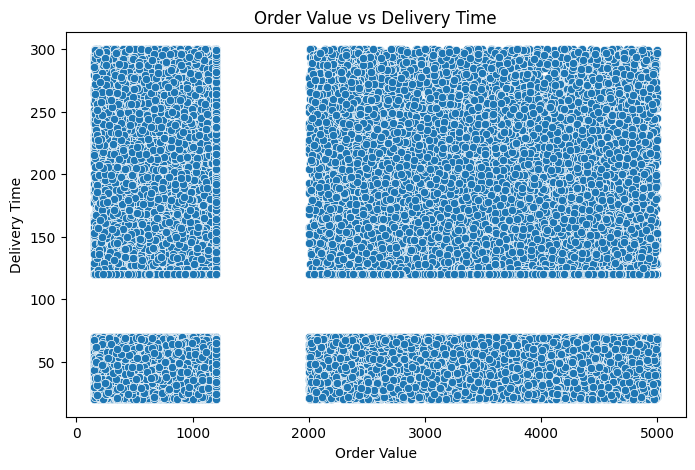

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1.Distribution of order values and delivery time
plt.figure(figsize=(8,5))
sns.scatterplot(x='Order_Value', y='Delivery_Time_Min', data=df)
plt.title("Order Value vs Delivery Time")
plt.xlabel("Order Value")
plt.ylabel("Delivery Time")
plt.show()




In [ ]:
#Insights:
#    1.The points are heavily scattered across all order values.
#    2.Low-value orders (₹0–₹1200) have both low and very high delivery times,High-value orders (₹2000–₹5000) also show wide variation in delivery time.
#Conclusion:
#    Order value does NOT strongly influence delivery time.
#Delivery Delay reasons may be:
#    1.Distance
#    2.Restaurant prep time
#    3.Peak hours

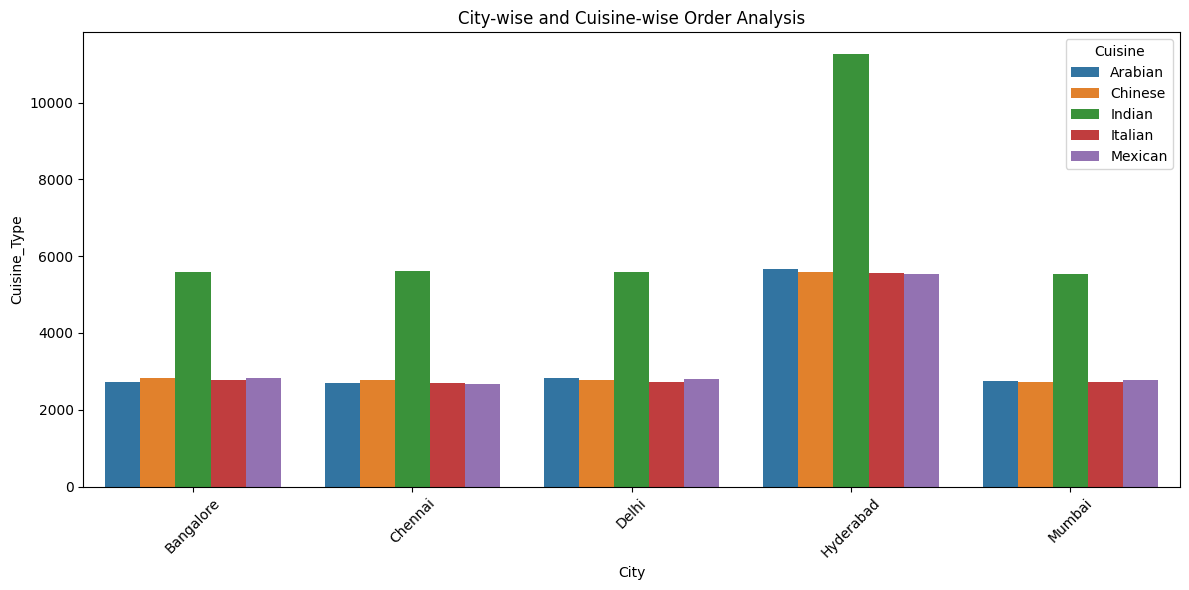

In [ ]:
#2.City-wise and cuisine-wise order analysis
plt.figure(figsize=(12,6))

sns.countplot(data=df, x='City', hue='Cuisine_Type')
plt.xticks(rotation=45)
plt.title("City-wise and Cuisine-wise Order Analysis")
plt.xlabel("City")
plt.ylabel("Cuisine_Type")
plt.legend(title="Cuisine")
plt.tight_layout()
plt.show()


In [ ]:
#Insights:
#       1.indian cuisine is most dominating cuisine in all cities.
#       2.Hyderabad stands out with the highest overall count, especially Indian cuisine.
#       3.other cuisines have equal popularity among all cities.
#Busisness ideas:
#       1.offer combo with best selling cuisines.
#       2.offer cashback for specific cuisines.
#       3.Run a weekly offers for all cuisines.

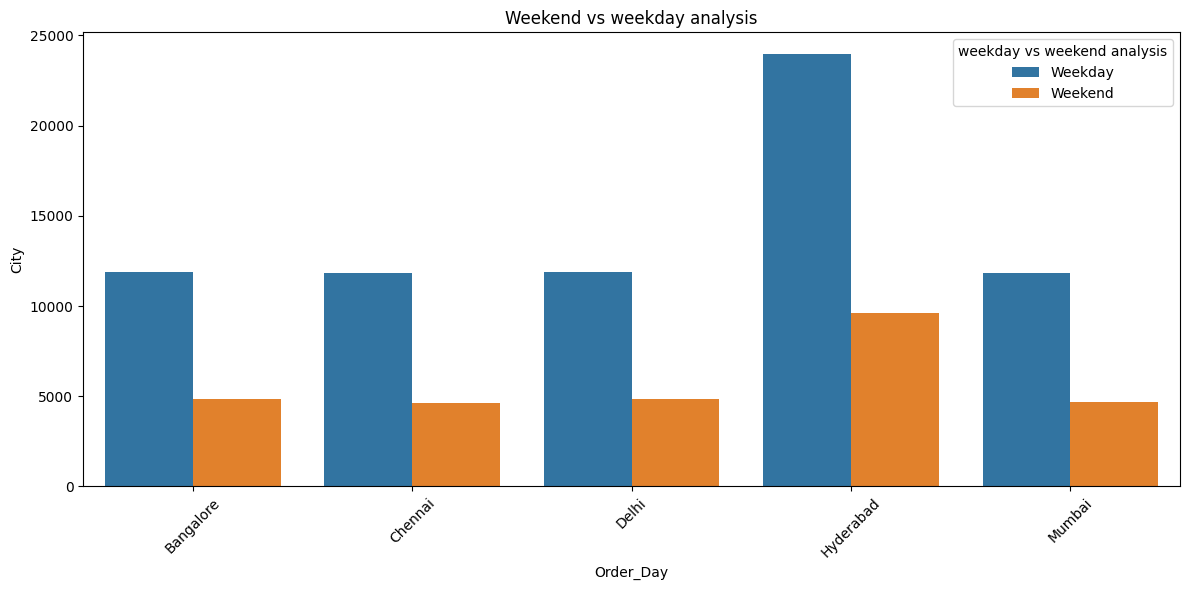

In [ ]:
# 3.Weekend vs weekday demand

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='City', hue='Order_Day')
plt.xticks(rotation=45)
plt.title("Weekend vs weekday analysis")
plt.xlabel("Order_Day")
plt.ylabel("City")
plt.legend(title="weekday vs weekend analysis")
plt.tight_layout()
plt.show()

In [ ]:
#Insights:
#       1.weekday orders are more higher than weekend orders.
#       2.Hyderabad city contributes more weekday orders compared to other cities.
#Busisness ideas:
#       1.Free delivery on weekends.
#       2.giving Discounts.
#       3.combo offers.


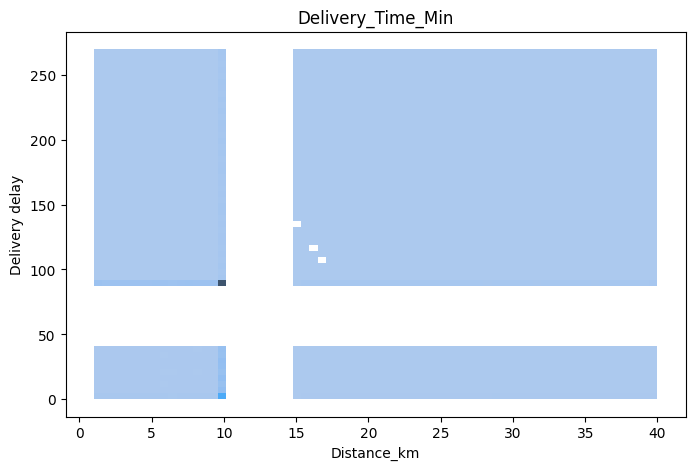

In [ ]:
# 4.Distance vs delivery delay relationship
expected_time = 30 #assumption

df['Delivery_Delay'] = df['Delivery_Time_Min'] - expected_time
df['Delivery_Delay'] = df['Delivery_Delay'].clip(lower=0)
plt.figure(figsize=(8,5))
sns.histplot(x='Distance_km', y='Delivery_Delay', data=df)
plt.title("Delivery_Time_Min")
plt.xlabel("Distance_km")
plt.ylabel("Delivery delay")
plt.show()

In [ ]:
# finding correlation between delivery delay and distance_km
correlation = df['Delivery_Delay'].corr(df['Distance_km']).item()
correlation

0.0023594367017855298

In [ ]:
#Insights:
#    1.For 0–10 km, delay ranges from very low (~10 min) to very high (~250+ min),For 15–40 km, delay is also widely spread (~20 min to 270 min).
#    2.There is no clear strong linear relationship,Even short-distance orders are experiencing very high delays.
#    This means Distance alone is not the main reason for delay.
#It might inclide:
#    1.Restaurant preparation delay
#     2.Rider assignment delay
#     3.Order batching issues
#     4.Peak hour congestion
#Buisness ideas:
#     1.Increase delivery partners in these cities
#     2.Use route optimization
#     3.Add more restaurant hubs

/tmp/ipykernel_223/4140518979.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


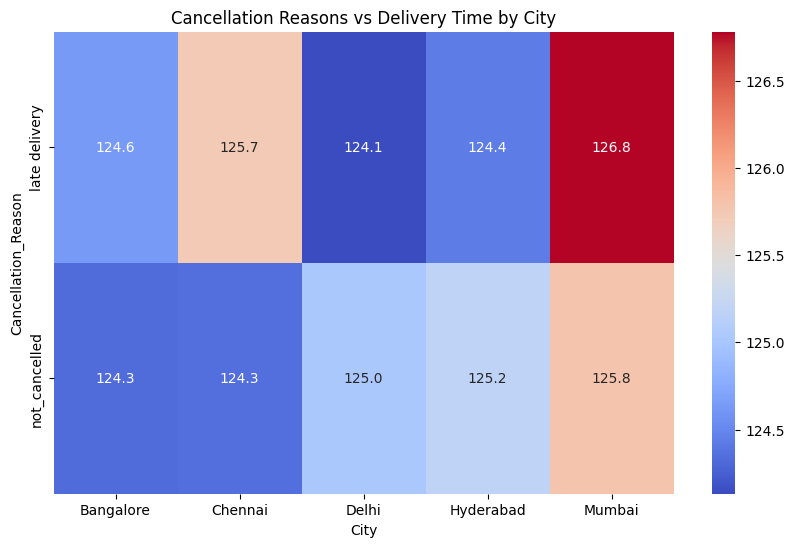

In [ ]:

#5.Cancellation reasons analysis
pivot_table = df.pivot_table(
    values='Delivery_Time_Min',
    index='Cancellation_Reason',
    columns='City',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Cancellation Reasons vs Delivery Time by City")
plt.show()

In [ ]:
#Insights:
#     1.Most of the cancellation reasons are due to late delivery.
#     2.Mumbai city is in the first place to cancel the orders and bangalore has least cancelled orders.
#Buisness ideas:
#     1.Increase delivery partners in these cities
#     2.Use route optimization
#     3.Add more restaurant hubs

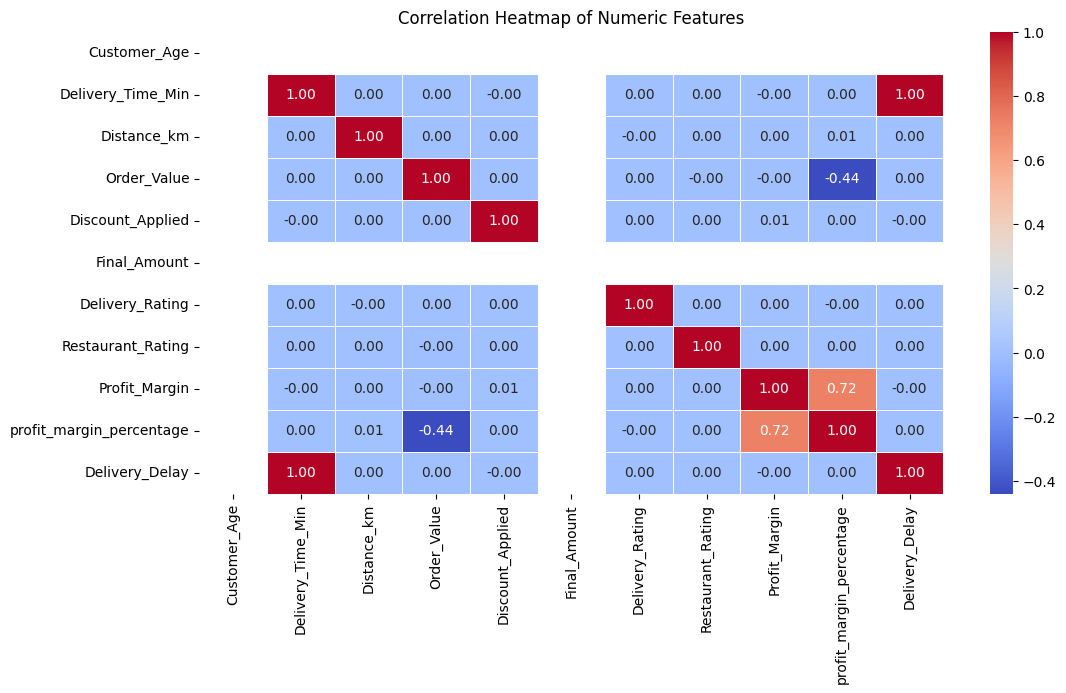

In [ ]:
# 6.Correlation analysis among numeric features

numeric = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric.corr()

plt.figure(figsize=(12,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()


Insights:
     There is no correlation among most of numeric features.

**Analyst Tasks (EDA & Analytics)
Customer & Order Analysis**

/tmp/ipykernel_223/2328211914.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Customer_ID', y='Order_Value',palette=colors)


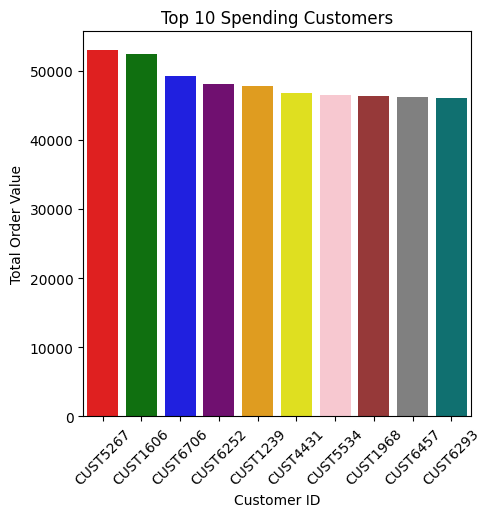

In [ ]:
# 1.Top spending customers
# Calculate total spending per customer
top_10 = (
    df.groupby("Customer_ID")["Order_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
# Visualization
plt.figure(figsize=(5,5))
colors='red','green','blue','purple','orange','yellow','pink','brown','grey','teal'
sns.barplot(data=top_10, x='Customer_ID', y='Order_Value',palette=colors)
plt.title("Top 10 Spending Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Order Value")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Insights:
#Revenue Contribution
#A small group of customers contributes a large portion of total revenue,Indicates presence of high-value customers.
#High spending may indicate repeat purchases,these customers are important for retention strategies.
# Business Recommendations:
#     1.Offer loyalty rewards.
#     2.Provide exclusive discounts.
#     3.Introduce premium membership plans.
#     4.Target similar customer segments.

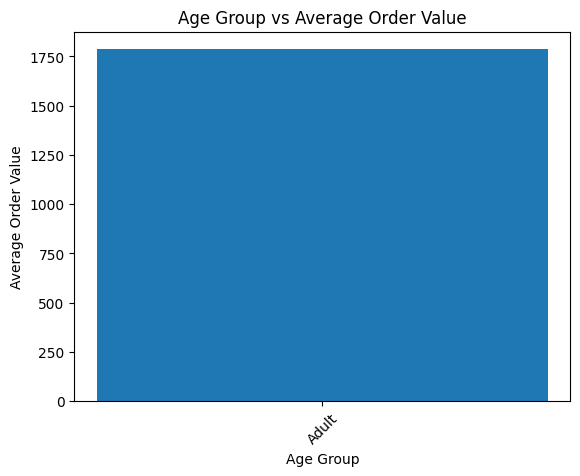

In [ ]:
# 2.Analyze age group vs order value
age_order_value = df.groupby('Age_Group')['Order_Value'].sum().reset_index()

age_order_value

# visualization

# Grouping data
age_analysis = df.groupby("Age_Group")["Order_Value"].mean().reset_index()

# Plot
plt.figure()
plt.bar(age_analysis["Age_Group"], age_analysis["Order_Value"])
plt.xlabel("Age Group")
plt.ylabel("Average Order Value")
plt.title("Age Group vs Average Order Value")
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Insights:
#    1.Adults customers contribute more in ordering food.
#    2.younger people(age<18) spent less compared to others.
#    3.Likely working professionals with higher purchasing power.
#    4.The group with highest total_spent contributes most revenue.

Order_Day
Weekday    71370
Weekend    28630
Name: count, dtype: int64


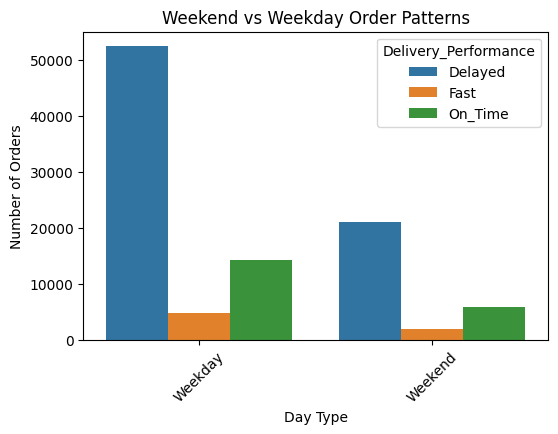

In [ ]:
# 3.Weekend vs weekday order patterns
order_counts = df['Order_Day'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='Order_Day',hue='Delivery_Performance',
    order=['Weekday', 'Weekend']
)

plt.title("Weekend vs Weekday Order Patterns")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Insights:
#    1.Weekday demand is higher, possibly due to working professionals ordering lunch and dinner.
# Business Implications:
#   If Weeday orders is greater than Weekends
#      1.Increase delivery partners on weekends
#      2.Run weekend special offers


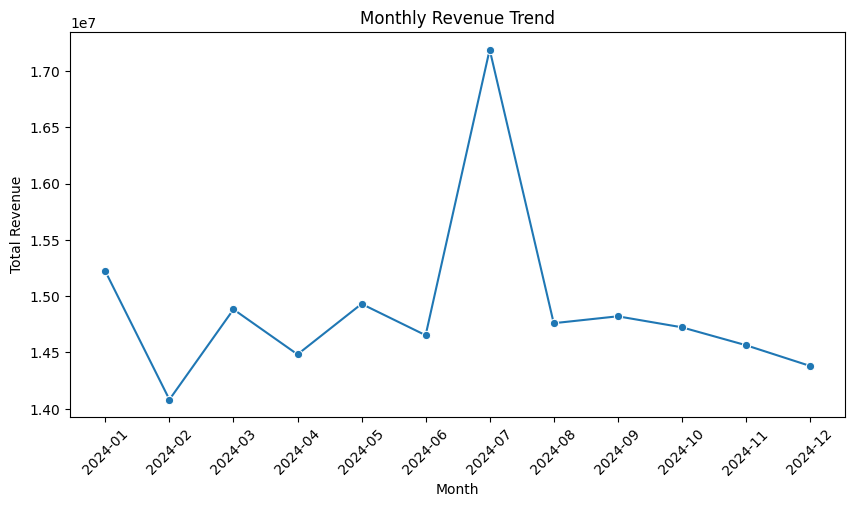

In [ ]:
# 4.Monthly revenue trends
df['Year_Month'] = df['Order_Date'].dt.to_period('M')
monthly_revenue = df.groupby('Year_Month')['Order_Value'].sum().reset_index()

# Convert period to string for plotting
monthly_revenue['Year_Month'] = monthly_revenue['Year_Month'].astype(str)
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x='Year_Month', y='Order_Value', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Insights:
#       1.Revenue increased steadily over the months.
#       2.Some months show peak revenue indicating high demand.
#       3.A drop in revenue suggests seasonal slowdown or operational challenges.
#       4.Revenue peaks during specific months, possibly due to festivals, holidays, or promotions.
#       5.Consistent revenue across months indicates stable customer demand.

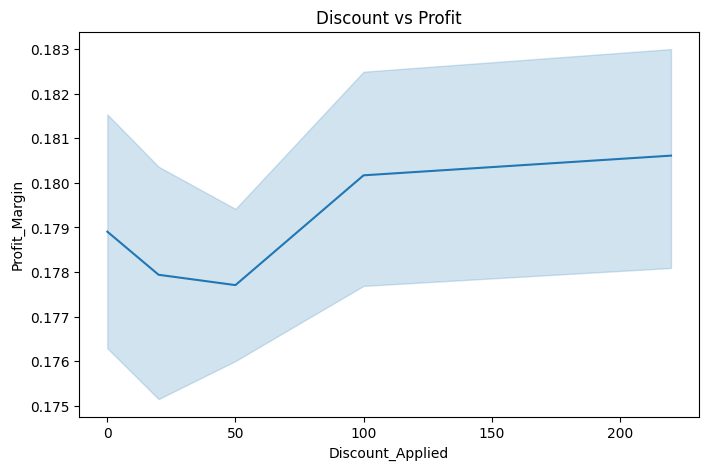

In [ ]:
# 5.Impact of discounts on profit
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.lineplot(x='Discount_Applied', y='Profit_Margin', data=df)
plt.title("Discount vs Profit")
plt.show()

In [ ]:
#Insights:
#    1.when discount is apllied a small amount(0 to 50) slightly affecta the profit margin.
#    2.when discount is slightly increased from 50,the profit_margin increases and stabilizes,
#    suggesting that moderate to higher discounts can improve overall profitability.
#    3.Extremely high discounts may increase order volume but significantly reduce overall profit.
#Business Recommendations:
#    1.Avoid excessive discounts (>40%)
#    2.Use targeted discounts instead of blanket offers
#    3.Apply discounts during low-demand periods
#    4.Optimize pricing strategy

/tmp/ipykernel_223/2092243390.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_revenue = df.groupby("City")["Order_Value"].sum().reset_index()


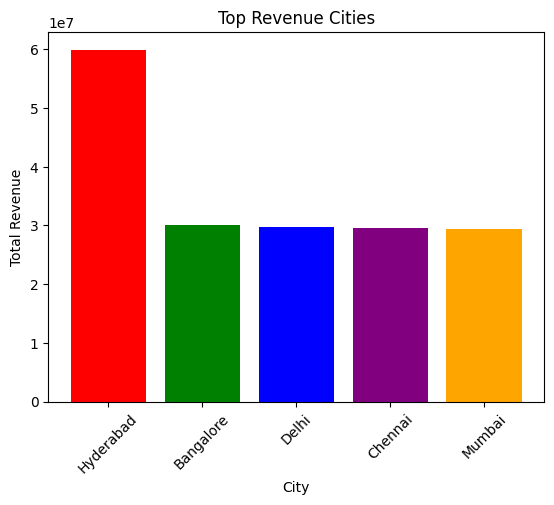

In [ ]:
# 6.High-revenue cities and cuisines

city_revenue = df.groupby("City")["Order_Value"].sum().reset_index()
city_revenue = city_revenue.sort_values(by="Order_Value", ascending=False)
plt.figure()
colors='red','green','blue','purple','orange'
plt.bar(city_revenue["City"], city_revenue["Order_Value"],color=colors)
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Top Revenue Cities")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Insights:
#      1.Hyderabad city contributes more revenue indicates strong customer base and hign demand
#      2.other cities perform moderate level of revenue
#      3.need to improve growth oppurtunities through offers and promtions.


/tmp/ipykernel_223/3715126239.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cuisine_revenue = df.groupby("Cuisine_Type")["Order_Value"].sum().reset_index()


  Cuisine_Type  Order_Value
2       Indian   60314705.0
4      Mexican   29765117.0
1      Chinese   29757833.0
0      Arabian   29481102.0
3      Italian   29375522.0


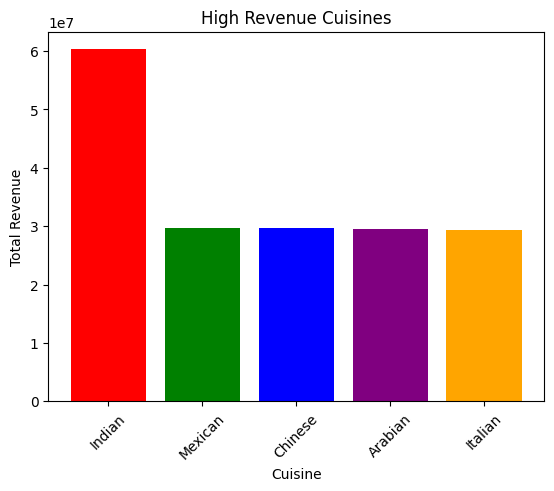

In [ ]:
# visualization for cuisine wise total revenue

# Group by cuisine
cuisine_revenue = df.groupby("Cuisine_Type")["Order_Value"].sum().reset_index()

# Sort descending
cuisine_revenue = cuisine_revenue.sort_values(by="Order_Value", ascending=False)
# Plot
plt.figure()
colors='red','green','blue','purple','orange'
plt.bar(cuisine_revenue["Cuisine_Type"], cuisine_revenue["Order_Value"],color=colors)
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue")
plt.title("High Revenue Cuisines")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Insights:
#     1.Indian cuisine contributes more in Total revenue
#     2.It indicates strong customer preferences and high spending per order.
#     3.Other cuisine perform moderate or same level in total revenue.
# Strategy:
#     1.Promote premium combos
#     2.Partner with more restaurants in this cuisine

/tmp/ipykernel_223/2057555963.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_delivery = df.groupby("City")["Delivery_Time_Min"].mean().reset_index()


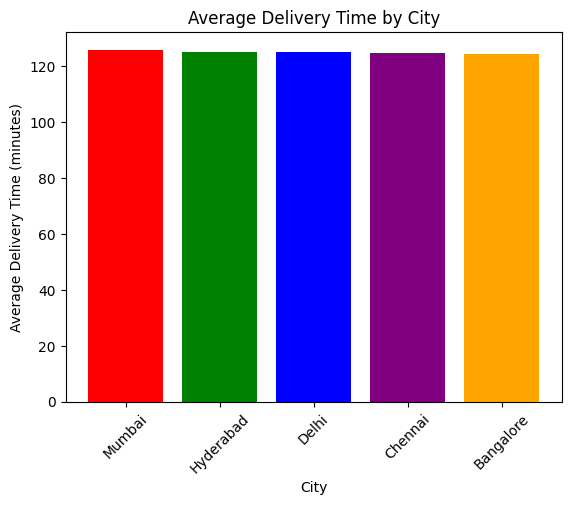

In [ ]:
# 7.Average delivery time by city
# Group by city
avg_delivery = df.groupby("City")["Delivery_Time_Min"].mean().reset_index()

# Sort (highest delivery time first)
avg_delivery = avg_delivery.sort_values(by="Delivery_Time_Min", ascending=False)
# Plot
plt.figure()
colors='red','green','blue','purple','orange'
plt.bar(avg_delivery["City"], avg_delivery["Delivery_Time_Min"],color=colors)
plt.xlabel("City")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Average Delivery Time by City")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Insights:
#     1.The average delivery time for all cities is by 120 minutes.
#     2.These cities are facing logistics challenges.
# Possible reasons:
#     1.Heavy traffic
#     2.Longer delivery distances
#     3.High order volume
#     4.Restaurant preparation delays
#  Business Action:
#     1.Increase delivery partners in these cities
#     2.Use route optimization
#     3.Add more restaurant hubs

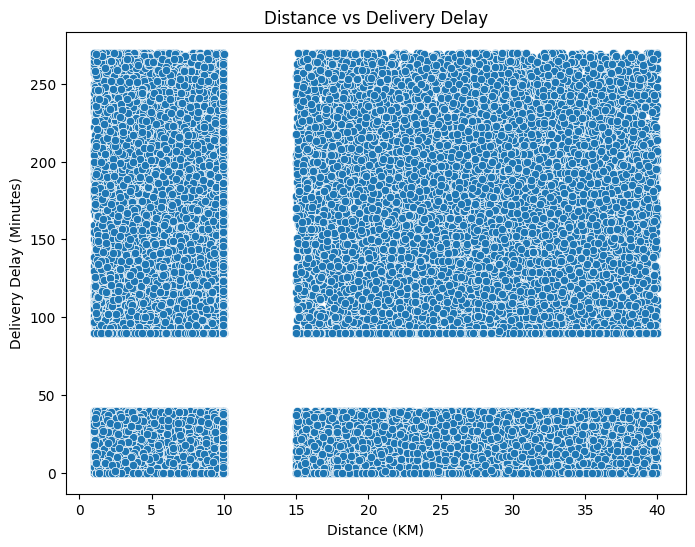

In [ ]:
#8.Distance vs delivery delay analysis
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Distance_km"],
    y=df["Delivery_Delay"]
)
plt.title("Distance vs Delivery Delay")
plt.xlabel("Distance (KM)")
plt.ylabel("Delivery Delay (Minutes)")
plt.show()

In [ ]:
# Insights:
#     1.No Strong Linear Relationship,the scatter does not show a clear upward slope.
#  This means:
#     1.Distance is not the only major factor causing delivery delay.
#     2.Other operational factors are influencing delay.
# Delay Even at Short Distance,Many points at low distance but high delay (above 150–300 mins).
# This indicates:
#     1.Restaurant preparation delay
#     2.Rider allocation problems
#     3.Traffic congestion
#     4.System inefficiencies
#     5.Distance alone is NOT responsible.

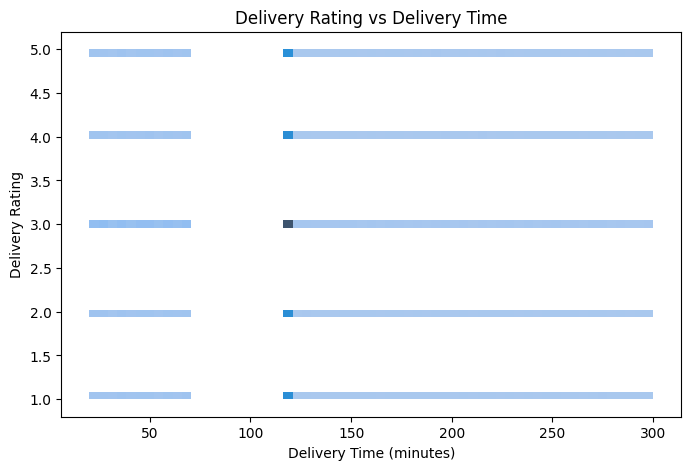

In [ ]:
# 9.Delivery rating vs delivery time

plt.figure(figsize=(8,5))
sns.histplot(
    x="Delivery_Time_Min",
    y="Delivery_Rating",
    data=df
)
plt.title("Delivery Rating vs Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Delivery Rating")
plt.show()

In [ ]:
#Insights:
#   1.No Strong Relationship Between Time and Rating
#   2.The plot does not show a clear downward trend.
# This means:
#   1.Longer delivery time does NOT consistently reduce ratings.
#   2.Rating is not strongly dependent on delivery time alone.
# Ratings Are Spread Across All Time Values
# Rating 5 exists for both short and long delivery times.
# Rating 1 also exists for both short and long delivery times.
# This suggests:
# Customers may consider other factors:
#   1.Food quality
#   2.Packaging
#   3.Delivery person behavior
#   4.App experience

/tmp/ipykernel_223/914177039.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


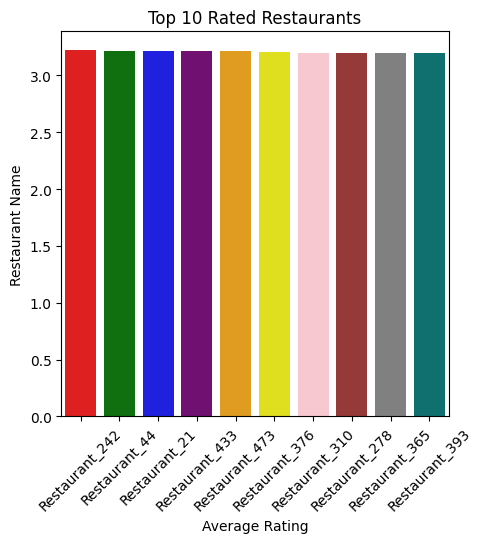

In [ ]:
# 10.Top-rated restaurants
# Calculate average rating per restaurant
top_restaurants = (
    df.groupby("Restaurant_Name")["Delivery_Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()

)
plt.figure(figsize=(5,5))
colors='red','green','blue','purple','orange','yellow','pink','brown','grey','teal'
sns.barplot(
    x="Restaurant_Name",
    y="Delivery_Rating",
    data=top_restaurants,palette=colors
)
plt.title("Top 10 Rated Restaurants")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Name")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Insights:
# These restaurants consistently receive higher customer satisfaction.
# Likely strong in food quality and service.
# Rating Difference,If ratings are close (e.g., 4.6 vs 4.5), competition is tight.
# If one restaurant is far ahead, it is clearly outperforming others.
# Business Insight:
#     1.Should be promoted more.
#     2.Can be used as benchmark for service quality.
#     3.May have better operational efficiency.

                 total_orders  cancelled_orders  cancellation_rate (%)
Restaurant_Name                                                       
Restaurant_391            196                43              21.938776
Restaurant_390            201                44              21.890547
Restaurant_477            176                38              21.590909
Restaurant_202            204                44              21.568627
Restaurant_373            191                41              21.465969
Restaurant_426            212                45              21.226415
Restaurant_299            194                41              21.134021
Restaurant_455            180                38              21.111111
Restaurant_113            205                43              20.975610
Restaurant_232            177                37              20.903955


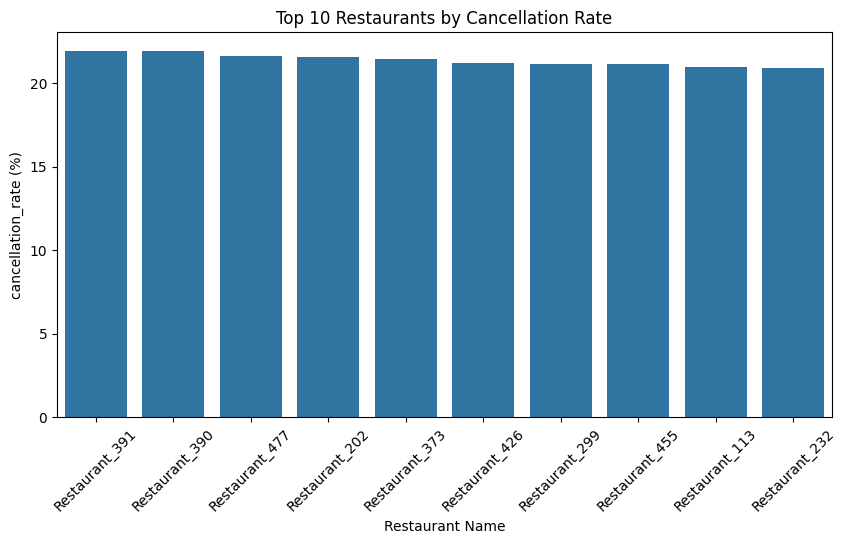

In [ ]:
# 11.Cancellation rate by restaurant
# Create cancellation flag (1 if cancelled, 0 otherwise)
df["is_cancelled"] = df["Order_Status"].apply(lambda x: 1 if x == "Cancelled" else 0)

# Group by restaurant
cancellation_rate = df.groupby("Restaurant_Name").agg(
    total_orders=("Order_Status", "count"),
    cancelled_orders=("is_cancelled", "sum")
)

# Calculate cancellation percentage
cancellation_rate["cancellation_rate (%)"] = (
    cancellation_rate["cancelled_orders"] / cancellation_rate["total_orders"] * 100
)

# Sort by highest cancellation rate
cancellation_rate = cancellation_rate.sort_values(
    "cancellation_rate (%)", ascending=False
)

top_cancel = cancellation_rate.head(10).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_cancel,
    x="Restaurant_Name",
    y="cancellation_rate (%)"
)

plt.title("Top 10 Restaurants by Cancellation Rate")
plt.xlabel("Restaurant Name")
plt.ylabel("cancellation_rate (%)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Insights:
# High Cancellation Rate Restaurants
# These restaurants may have:
#     1.Long preparation time
#     2.Frequent stock shortages
#     3.Poor customer experience
# Low Cancellation Rate Restaurants
#     2.Likely operationally efficient
#     2.Better customer satisfaction
#     3.Reliable service
# Business Recommendation
#     1.Investigate top 5 high-cancellation restaurants
#     2.Improve order confirmation system
#     3.Monitor food preparation time

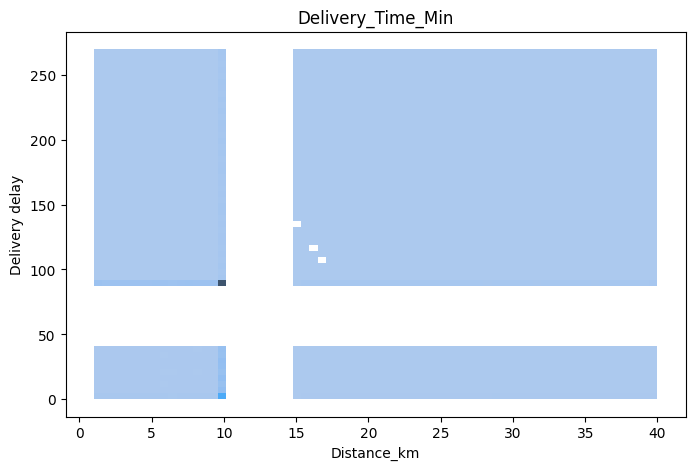

In [ ]:
# 12..Distance vs delivery delay relationship
expected_time = 30 #assumption
df['Delivery_Delay'] = df['Delivery_Time_Min'] - expected_time
df['Delivery_Delay'] = df['Delivery_Delay'].clip(lower=0)
plt.figure(figsize=(8,5))
sns.histplot(x='Distance_km', y='Delivery_Delay', data=df)
plt.title("Delivery_Time_Min")
plt.xlabel("Distance_km")
plt.ylabel("Delivery delay")
plt.show()

In [ ]:
#Insights:
# 1.From the scatter pattern,There is no strong linear relationship between distance and delivery delay,Delays vary widely even at similar distances.
# 2.This suggests distance alone does not fully explain delivery delays.
# 3.Delay at Short Distances,You may observe,High delivery delays even for short distances.
# This indicates:
#      1.Restaurant preparation delays
#      2.Rider assignment issues
#      3.Traffic congestion
#      4.Operational inefficiencies
# Distance is not the main bottleneck here.
# High Variability,For the same distance:
# Some orders are delivered quickly,Others are heavily delayed
# This shows inconsistency in delivery operations

[0]


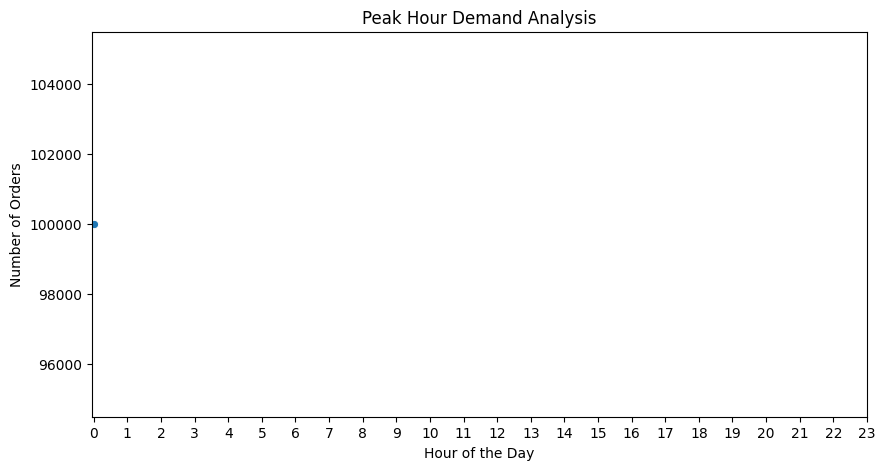

In [ ]:
# 13.Peak hour demand analysis
df["Order_Time"] = pd.to_datetime(df["Order_Time"])
df["order_hour"] = df["Order_Time"].dt.hour
hourly_orders = df.groupby("order_hour").size().reset_index(name="total_orders")
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_orders, x="order_hour", y="total_orders", marker="o")
plt.title("Peak Hour Demand Analysis")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0,24))
plt.show()

In [ ]:
#Insights:
# 1.The peak hour of the analysis is at 12.00 am.
# 2.Here we have Order_date feaure only and the order time feature in  our dataset consists of 0.00 values for all rows.
# 3.so here Peak hour analysis is not possible.
# 4.In future if we have meaningful datas means it is posiible to find the peak hour for analysis.


  Payment_Mode  total_orders
0         Card         40005
1       Wallet         20086
2          COD         19977
3          UPI         19932


/tmp/ipykernel_223/845652932.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_counts,


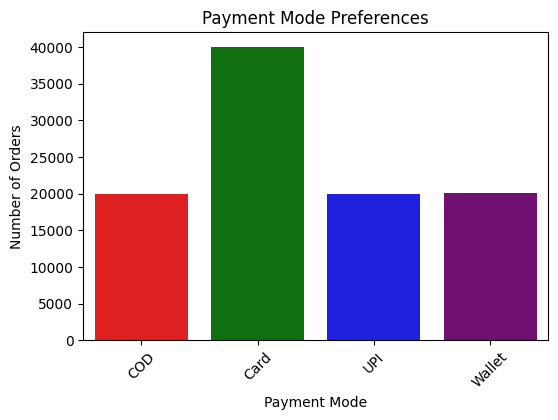

In [ ]:
# 14.Payment mode preferences
payment_counts = df["Payment_Mode"].value_counts().reset_index()
payment_counts.columns = ["Payment_Mode", "total_orders"]
plt.figure(figsize=(6,4))
colors='red','green','blue','purple'
sns.barplot(data=payment_counts,
            x="Payment_Mode",
            y="total_orders",palette=colors)
plt.title("Payment Mode Preferences")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Insights:
#    1.payment by UPI is the most used payment mehod.
#    2.It indicates customer trust and convenience.
#    3.Customers prefer digital payment methods, showing growing adoption of cashless transactions.
# Business Implications
#    1.Promote popular payment methods.
#    2.Offer cashback on less-used methods.
#    3.Partner with digital wallets for offers.

/tmp/ipykernel_223/1257963798.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


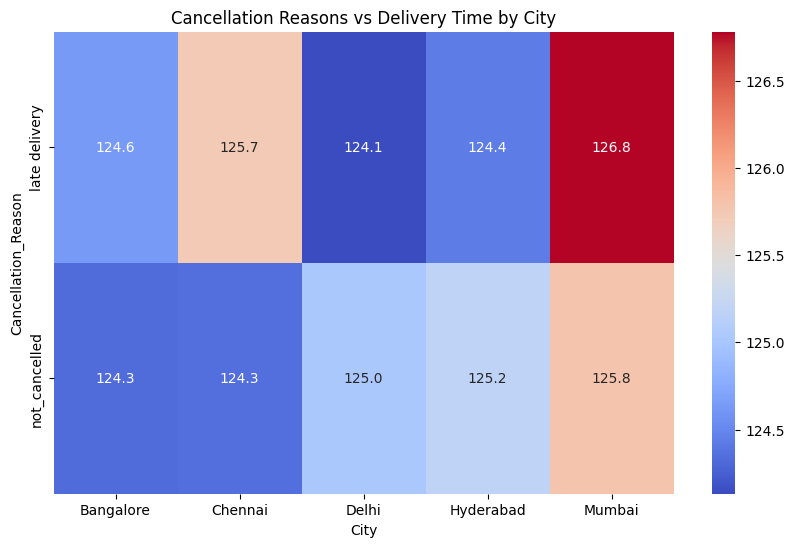

In [ ]:
# 15.Cancellation reason analysis
pivot_table = df.pivot_table(
    values='Delivery_Time_Min',
    index='Cancellation_Reason',
    columns='City',
    aggfunc='mean'
)
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Cancellation Reasons vs Delivery Time by City")
plt.show()

In [ ]:
#Insights:
#    1.The major reason for cancelled orders is late delivery.
#    2.Delivery performance needs improvement during peak hours.
#Buissness Ideas:
#    1.Improve rider allocation system
#    2.Monitor restaurant preparation time
#    3.Send accurate delivery time estimates
#    4.Reduce peak-hour overload